In [3]:
import ipywidgets as widgets
from ipywidgets import Button, HTML,HBox,Accordion
import pandas as pd
import numpy as np
import os
import time
import re
import importlib
import matplotlib.pyplot as plt

#from IPython.core.display import display

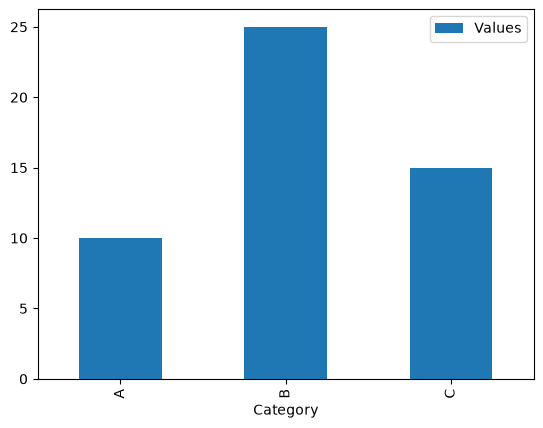

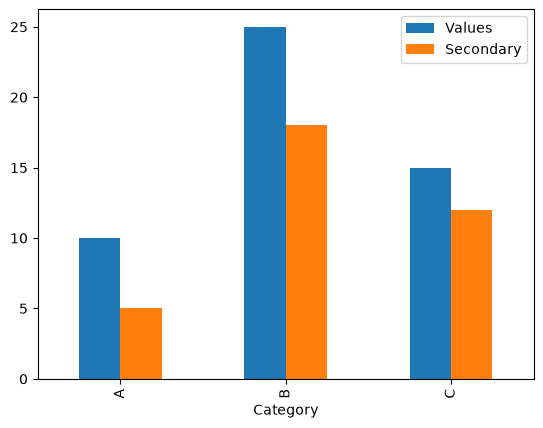

In [21]:
data = {'Category': ['A', 'B', 'C'], 'Values': [10, 25, 15], 'Secondary': [5, 18, 12]}
tdf = pd.DataFrame(data)
# Plot a single column vs another
tdf.plot.bar(x='Category', y='Values')
plt.show()

# Plot all numerical columns grouped by the index
tdf.set_index('Category').plot.bar()
plt.show()

In [4]:
print(os.getcwd())

C:\Users\e453331\OneDrive - Lockheed Martin US\GitRepos\CACM\laptop\python\JupyterNotebooks


In [22]:
df = pd.read_csv("..\\..\\.output\\20260909_162309-STRM100_66_93_65_50608_12000_MissingSeq.csv")
df.columns = df.columns.str.strip()

In [23]:
display(df)

,StartTime,DeltaT,SequenceNumber,MissingCount,MissingDurationSeconds
0,2026-09-09 22:23:09.441596700,0.047310,2,4,0.00000
1,2026-09-09 22:23:09.441922700,0.000326,3,6,0.00000
2,2026-09-09 22:23:09.443218300,0.001300,4,3,0.00000
3,2026-09-09 22:23:09.443366900,0.000149,5,8,0.00000
4,2026-09-09 22:23:09.443660300,0.000293,6,6,0.00000
...,...,...,...,...,...
24168,2026-09-09 23:19:27.208578900,0.269200,33775072,1,0.02122
24169,2026-09-09 23:19:28.048931300,0.840350,33783989,1,0.10229
24170,2026-09-09 23:19:29.031188400,0.982260,33793097,1,0.01607
24171,2026-09-09 23:19:29.521562300,0.490370,33798132,1,0.01528


In [24]:
df.columns

Index(['StartTime', 'DeltaT', 'SequenceNumber', 'MissingCount',
       'MissingDurationSeconds'],
      dtype='object')

In [25]:
df['MissingCount'].max()
max_row = df.loc[df['MissingCount'].idxmax()]
display(max_row)

StartTime                 2026-09-09 22:51:26.533912000
DeltaT                                          0.07123
SequenceNumber                                 16971924
MissingCount                                     997948
MissingDurationSeconds                             99.8
Name: 9345, dtype: object

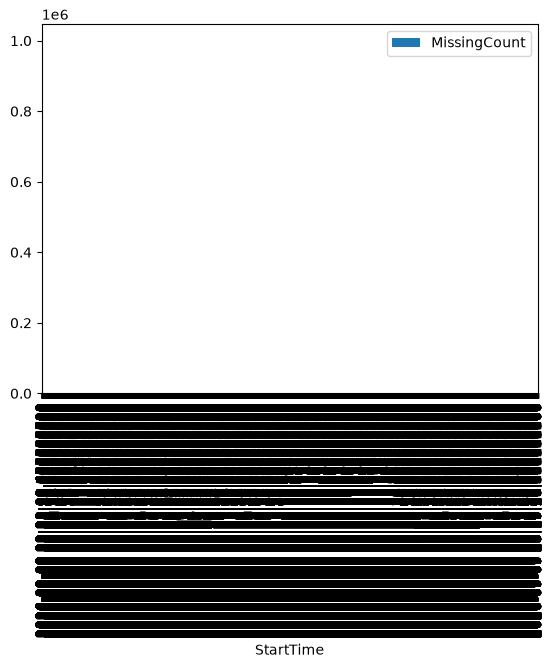

In [26]:
#df.set_index('StartTime')
df.plot.bar(x='StartTime', y='MissingCount')
plt.show()


In [28]:
df.columns

Index(['StartTime', 'DeltaT', 'SequenceNumber', 'MissingCount',
       'MissingDurationSeconds'],
      dtype='object')

In [30]:
# Aggregate close Missing
df_new = df.iloc[0:0].copy()
startTime = None
count = 0
duration = 0
seq_num = 0
deltaT = 0
for index, row in df.iterrows():
    if row['DeltaT'] < 0.1:
        if startTime is None:
            startTime = row['StartTime']
            seq_num = row['SequenceNumber']
            deltaT   = row['DeltaT']
        count += row['MissingCount']
        duration += row['MissingDurationSeconds']
    else:
        if startTime is None:
            df_new.loc[len(df_new)] = [row['StartTime'], row['DeltaT'], row['SequenceNumber'], row['MissingCount'], row['MissingDurationSeconds']]
        else: #Start a new record
            df_new.loc[len(df_new)] = [startTime, deltaT, seq_num, count, duration]
            startTime = row['StartTime']
            seq_num = row['SequenceNumber']
            deltaT   = row['DeltaT']
            count = row['MissingCount']
            duration = row['MissingDurationSeconds']

df_new.loc[len(df_new)] = [startTime, deltaT, seq_num, count, duration]
display(df_new)

,StartTime,DeltaT,SequenceNumber,MissingCount,MissingDurationSeconds
0,2026-09-09 22:23:09.441596700,0.04731,2,365,0.098227
1,2026-09-09 22:23:09.678809100,0.20186,2247,5,0.216400
2,2026-09-09 22:23:09.850117500,0.10570,4035,1,0.052530
3,2026-09-09 22:23:09.957335500,0.10722,5402,1,0.027540
4,2026-09-09 22:23:10.068175400,0.11084,6107,4,0.176570
...,...,...,...,...,...
6928,2026-09-09 23:19:27.208578900,0.26920,33775072,1,0.021220
6929,2026-09-09 23:19:28.048931300,0.84035,33783989,1,0.102290
6930,2026-09-09 23:19:29.031188400,0.98226,33793097,1,0.016070
6931,2026-09-09 23:19:29.521562300,0.49037,33798132,1,0.015280


In [43]:
df.describe()

,DeltaT,SequenceNumber,MissingCount,MissingDurationSeconds
count,24173.000000,2.417300e+04,24173.000000,24173.000000
mean,0.139837,1.730201e+07,82.733918,2.054011
std,0.721136,9.311130e+06,6523.165478,10.953314
min,-0.027320,2.000000e+00,1.000000,0.000000
25%,0.000121,9.354563e+06,1.000000,0.012310
50%,0.012000,2.106213e+07,1.000000,0.025390
75%,0.118590,2.195876e+07,2.000000,0.066630
max,100.560000,3.379972e+07,997948.000000,101.210000


In [36]:
df_new['StartTime'] = pd.to_datetime(df_new['StartTime'])
df_new['RelativeTime'] = df_new['StartTime'] - df_new['StartTime'].iloc[0]
df_new['RelativeTimeSec'] = df_new['RelativeTime'] .dt.total_seconds()
display(df_new)

,StartTime,DeltaT,SequenceNumber,MissingCount,MissingDurationSeconds,RelativeTime,RelativeTimeSec
0,2026-09-09 22:23:09.441596700,0.04731,2,365,0.098227,0 days 00:00:00,0.000000
1,2026-09-09 22:23:09.678809100,0.20186,2247,5,0.216400,0 days 00:00:00.237212400,0.237212
2,2026-09-09 22:23:09.850117500,0.10570,4035,1,0.052530,0 days 00:00:00.408520800,0.408521
3,2026-09-09 22:23:09.957335500,0.10722,5402,1,0.027540,0 days 00:00:00.515738800,0.515739
4,2026-09-09 22:23:10.068175400,0.11084,6107,4,0.176570,0 days 00:00:00.626578700,0.626579
...,...,...,...,...,...,...,...
6928,2026-09-09 23:19:27.208578900,0.26920,33775072,1,0.021220,0 days 00:56:17.766982200,3377.766982
6929,2026-09-09 23:19:28.048931300,0.84035,33783989,1,0.102290,0 days 00:56:18.607334600,3378.607335
6930,2026-09-09 23:19:29.031188400,0.98226,33793097,1,0.016070,0 days 00:56:19.589591700,3379.589592
6931,2026-09-09 23:19:29.521562300,0.49037,33798132,1,0.015280,0 days 00:56:20.079965600,3380.079966


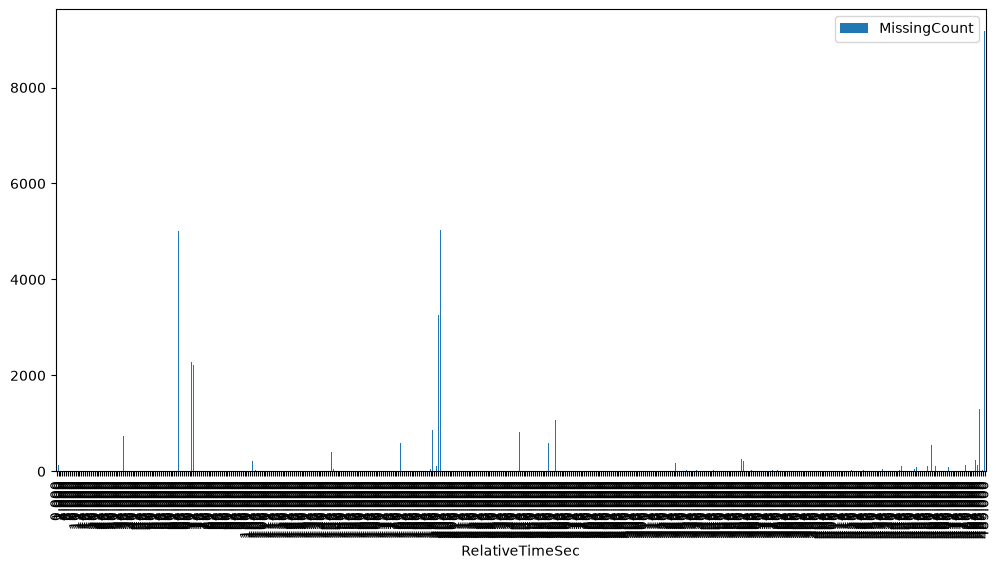

In [58]:
import matplotlib.ticker as ticker
df_plt= df_new
df_plt= df_new.iloc[10:500]
df_plt.set_index('RelativeTimeSec')
ax = df_plt.plot.bar(x='RelativeTimeSec', y='MissingCount', figsize=(12, 6))
#df.plot(figsize=(12, 6))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:.3f}"))
plt.show()

In [42]:
df_new.describe()

,StartTime,DeltaT,SequenceNumber,MissingCount,MissingDurationSeconds,RelativeTime,RelativeTimeSec
count,6933,6933.000000,6.933000e+03,6933.000000,6933.000000,6933,6933.000000
mean,2026-09-09 22:51:37.406065664,0.446124,1.708063e+07,288.464878,7.161632,0 days 00:28:27.964468967,1707.964469
min,2026-09-09 22:23:09.441596700,0.047310,2.000000e+00,1.000000,0.000000,0 days 00:00:00,0.000000
25%,2026-09-09 22:36:38.302312960,0.170760,8.089472e+06,1.000000,0.020200,0 days 00:13:28.860716200,808.860716
50%,2026-09-09 22:54:03.665144064,0.286270,1.854393e+07,2.000000,0.070860,0 days 00:30:54.223547400,1854.223547
75%,2026-09-09 23:05:34.856252672,0.519460,2.545399e+07,6.000000,0.113580,0 days 00:42:25.414655900,2545.414656
max,2026-09-09 23:19:29.657153200,100.560000,3.379972e+07,997949.000000,12374.880435,0 days 00:56:20.215556500,3380.215556
std,NaN,1.296101,9.934988e+06,12193.802603,169.791156,0 days 00:16:33.645594556,993.645595


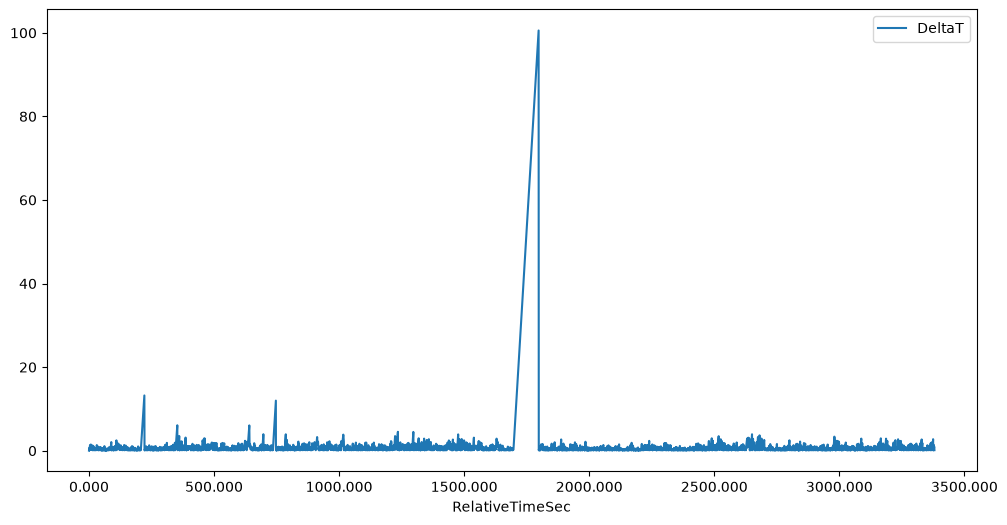

In [56]:
#df_plt= df_new.iloc[10:15]
df_plt= df_new
#df_plt.set_index('RelativeTimeSec')
ax = df_plt.plot(x='RelativeTimeSec', y='DeltaT', figsize=(12, 6))
#df.plot(figsize=(12, 6))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:.3f}"))
plt.show()

In [ ]:
trg_date = (pd.to_datetime('2026-03-02 07:23:35.5') - pd.Timestamp(base_date)).total_seconds()
print(f"trg={trg_date}")
abs_diff = (pixie_all_df['fsec'] - trg_date).abs()
closest_index_label = abs_diff.idxmin()

# Use the label to access the row in the original DataFrame
closest_row = pixie_all_df.loc[closest_index_label]

print(f"Closest index label: {closest_index_label}")
print(f"Closest row:\n{closest_row}")

# matches = pixie_all_df.index.get_indexer([trg_date], method='nearest').item
# print(f"matches={matches}")
# tout = pixie_all_df.iloc[matches]
# display(tout)
#closest_index_label = pixie_all_df.index[closest_index_pos[0]]
#closest_row = pixie_all_df.iloc[closest_index_pos[0]]
#print(f"cpos={closest_index_pos}")
# print(f"clbl={closest_index_label} crow={closest_row}")

In [ ]:
ard_df = pa.ProcessArduinoLogDir("C:\\Users\\e453331\\OneDrive - Lockheed Martin US\\Programs\\Corvette\\BNL202603\\Barry\\Arduino\\Arduino", pixie_all_df, base_date)
display(ard_df)

In [ ]:
# Process NSRL Files
df = pd.read_csv("C:\\Users\\e453331\\OneDrive - Lockheed Martin US\\Programs\\Corvette\\BNL202603\\NSRL\\nsrl_lmco_spill_data_2026-03-02.csv")
df2 = pd.read_csv("C:\\Users\\e453331\\OneDrive - Lockheed Martin US\\Programs\\Corvette\\BNL202603\\NSRL\\nsrl_lmco_spill_data_2026-03-03.csv")
nsrl_df = pd.concat([df, df2], ignore_index=True)
nsrl_df['time'] = pd.to_datetime(nsrl_df['time'])
nsrl_df['time'] = nsrl_df['time'] + pd.Timedelta(hours=-2) # convert to mountain time
nsrl_df['fsec'] = (nsrl_df['time'] - pd.Timestamp(base_date)).dt.total_seconds()
display(nsrl_df)

In [ ]:
# combine Pixie/Arduino (ard_df) with NSRL DF
combined_df = ard_df.copy(deep=True)
combined_df['ions/cm2'] = np.nan
for index, row in nsrl_df.iterrows():
    abs_diff = (combined_df['fsec'] - row['fsec']).abs()
    closest_index_label = abs_diff.idxmin()
    combined_df.loc[closest_index_label, 'ions/cm2'] = row['ions/cm2']
display(combined_df)

In [ ]:
df.dtypes
#df.columns

In [ ]:
combined_df.dtypes

In [ ]:
combined_df.to_csv("C:\\Users\\e453331\\OneDrive - Lockheed Martin US\\Programs\\Corvette\\BNL202603\\Barry\\CombinedCurrentData20260330.csv")

# Or Read the already processed CSV

In [9]:
combined_df = pd.read_csv("C:\\Users\\e453331\\OneDrive - Lockheed Martin US\\Programs\\Corvette\\BNL202603\\Barry\\CombinedCurrentData20260316.csv")
combined_df['Date (MM/DD/YYYY Hr:Min:Sec)'] = pd.to_datetime(combined_df['Date (MM/DD/YYYY Hr:Min:Sec)'])
display(combined_df)

,Unnamed: 0,Date (MM/DD/YYYY Hr:Min:Sec),Second Timer (sec),PXI1.PS1.CH1 Voltage (V),PXI1.PS1.CH1 Current (A),PXI1.PS2.CH0 Voltage (V),PXI1.PS2.CH0 Current (A),PXI1.PS3.CH0 Voltage (V),PXI1.PS3.CH0 Current (A),PXI1.PS5.CH0 Voltage (V),...,PXI1.PS2.CH0 Compliance,PXI1.PS3.CH0 Compliance,PXI1.PS5.CH0 Compliance,Beam State,Run Number,Event Tag,fsec,Core Current,0.75 Current,ions/cm2
0,0,2026-03-02 07:23:34.943,1645.3615,-0.003,-0.0,-0.0,0.0,-0.0,-0.0,-0.0,...,OFF,OFF,ON,OFF,1.0,NaN,26614.943,20.0,10.28,NaN
1,1,2026-03-02 07:23:35.142,1645.5607,0.000,0.0,-0.0,0.0,-0.0,0.0,-0.0,...,OFF,OFF,ON,OFF,1.0,NaN,26615.142,NaN,NaN,NaN
2,2,2026-03-02 07:23:35.343,1645.7612,-0.001,-0.0,-0.0,0.0,-0.0,0.0,-0.0,...,OFF,OFF,ON,OFF,1.0,NaN,26615.343,NaN,NaN,NaN
3,3,2026-03-02 07:23:35.543,1645.9611,-0.000,-0.0,-0.0,0.0,-0.0,0.0,-0.0,...,OFF,OFF,ON,OFF,1.0,NaN,26615.543,NaN,NaN,NaN
4,4,2026-03-02 07:23:35.742,1646.1607,0.002,-0.0,-0.0,0.0,-0.0,0.0,-0.0,...,OFF,OFF,ON,OFF,1.0,NaN,26615.742,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357193,357193,2026-03-03 15:59:15.250,118985.6684,0.000,-0.0,0.0,0.0,-0.0,0.0,-0.0,...,OFF,OFF,ON,OFF,79.0,NaN,143955.250,NaN,NaN,-0.579764
357194,357194,2026-03-03 15:59:15.450,118985.8684,0.001,-0.0,0.0,0.0,-0.0,0.0,-0.0,...,OFF,OFF,ON,OFF,79.0,NaN,143955.450,NaN,NaN,NaN
357195,357195,2026-03-03 15:59:15.650,118986.0686,0.004,-0.0,0.0,0.0,-0.0,0.0,-0.0,...,OFF,OFF,ON,OFF,79.0,NaN,143955.650,NaN,NaN,NaN
357196,357196,2026-03-03 15:59:15.850,118986.2684,-0.004,-0.0,0.0,0.0,-0.0,0.0,-0.0,...,OFF,OFF,ON,OFF,79.0,NaN,143955.850,NaN,NaN,NaN


# Plot Combined Data

In [ ]:
#fig, ax1 = plt.subplots()
plt.figure(figsize=(11, 8))
combined_df.plot(x="Date (MM/DD/YYYY Hr:Min:Sec)", 
                 y=['PXI1.PS1.CH1 Current (A)', 'PXI1.PS2.CH0 Current (A)', 'PXI1.PS3.CH0 Current (A)', 'PXI1.PS5.CH0 Current (A)'], 
                 #label="1.8V", 
                 kind='line')
fig.legend()
fig.figsize=(11,8)
plt.ylabel('Current (A)')
plt.show()

In [6]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))


## Select wether you want inline plots or separate Window

In [22]:
 # Make plots in a separate window
%matplotlib qt

# Make plots in a inline
#%matplotlib inline 

## Plot All

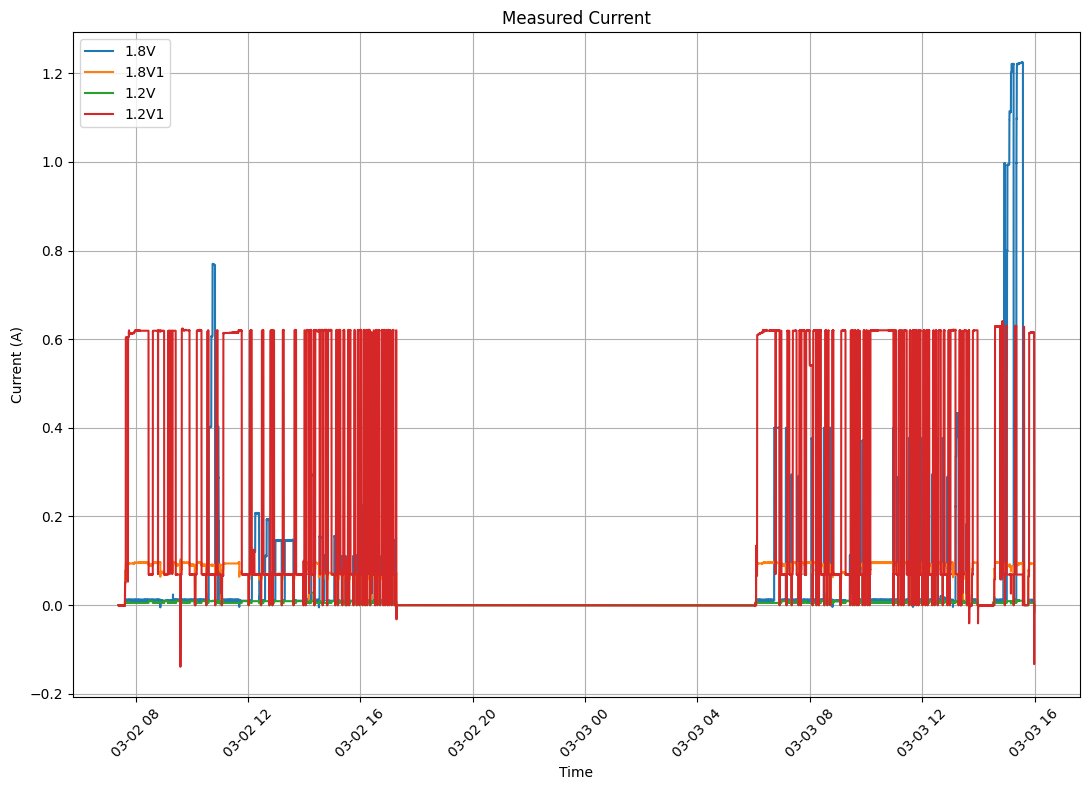

In [19]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
plt.figure(figsize=(11, 8))
plt.plot(combined_df["Date (MM/DD/YYYY Hr:Min:Sec)"], 
         combined_df['PXI1.PS1.CH1 Current (A)'], label="1.8V")
             #'PXI1.PS2.CH0 Current (A)', 'PXI1.PS3.CH0 Current (A)', 'PXI1.PS5.CH0 Current (A)'])
plt.plot(combined_df["Date (MM/DD/YYYY Hr:Min:Sec)"], 
         combined_df['PXI1.PS2.CH0 Current (A)'], label="1.8V1")
plt.plot(combined_df["Date (MM/DD/YYYY Hr:Min:Sec)"], 
         combined_df['PXI1.PS3.CH0 Current (A)'], label="1.2V")
plt.plot(combined_df["Date (MM/DD/YYYY Hr:Min:Sec)"], 
         combined_df['PXI1.PS5.CH0 Current (A)'], label="1.2V1")
# plt.plot(combined_df["Date (MM/DD/YYYY Hr:Min:Sec)"], 
#          combined_df['Core Current'], label="Core")
# plt.plot(combined_df["Date (MM/DD/YYYY Hr:Min:Sec)"], 
#          combined_df['0.75 Current'], label="0.75V")
plt.title("Measured Current")
plt.xlabel('Time')
plt.xticks(rotation=45)  # Rotate labels 45 degrees
plt.ylabel('Current (A)')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

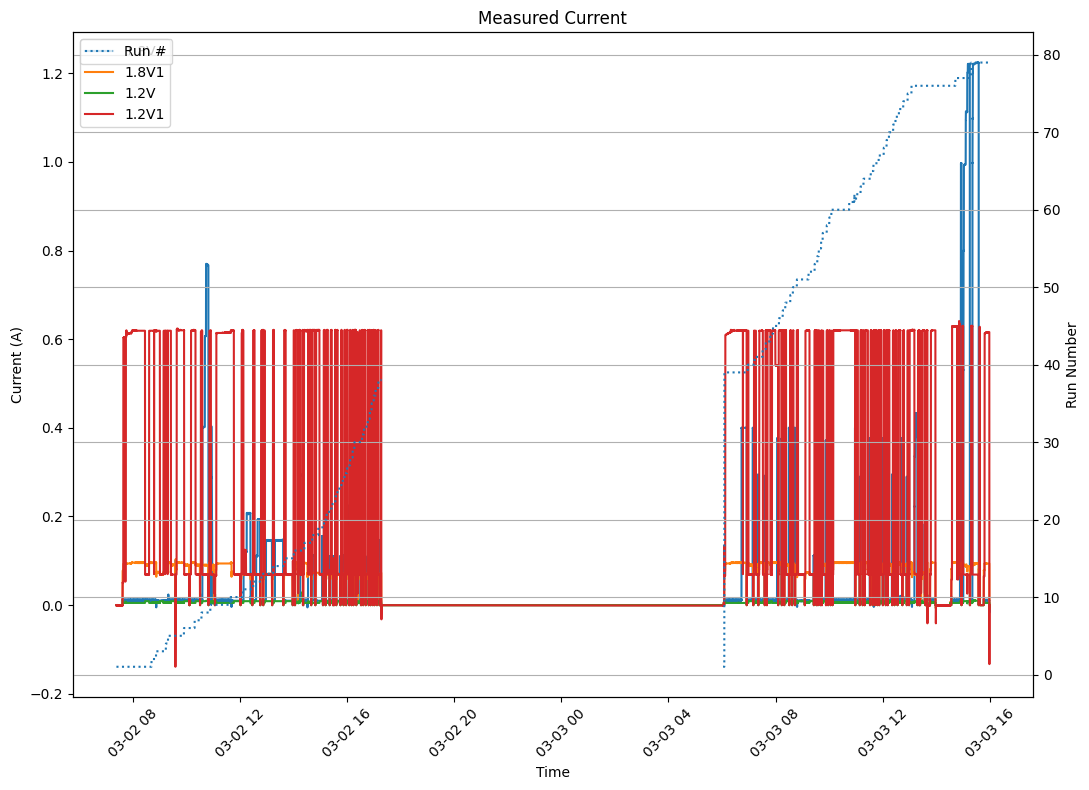

In [18]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
fig, ax1 = plt.subplots(figsize=(11, 8))
ax2 = ax1.twinx()
ax1.plot(combined_df["Date (MM/DD/YYYY Hr:Min:Sec)"], 
         combined_df['PXI1.PS1.CH1 Current (A)'], label="1.8V")
             #'PXI1.PS2.CH0 Current (A)', 'PXI1.PS3.CH0 Current (A)', 'PXI1.PS5.CH0 Current (A)'])
ax1.plot(combined_df["Date (MM/DD/YYYY Hr:Min:Sec)"], 
         combined_df['PXI1.PS2.CH0 Current (A)'], label="1.8V1")
ax1.plot(combined_df["Date (MM/DD/YYYY Hr:Min:Sec)"], 
         combined_df['PXI1.PS3.CH0 Current (A)'], label="1.2V")
ax1.plot(combined_df["Date (MM/DD/YYYY Hr:Min:Sec)"], 
         combined_df['PXI1.PS5.CH0 Current (A)'], label="1.2V1")
ax2.plot(combined_df["Date (MM/DD/YYYY Hr:Min:Sec)"], 
         combined_df['Run Number'], label="Run #", linestyle=':')
# plt.plot(combined_df["Date (MM/DD/YYYY Hr:Min:Sec)"], 
#          combined_df['Core Current'], label="Core")
# plt.plot(combined_df["Date (MM/DD/YYYY Hr:Min:Sec)"], 
#          combined_df['0.75 Current'], label="0.75V")
plt.title("Measured Current")
ax1.set_xlabel('Time')
plt.xticks(rotation=90)  # Rotate labels 45 degrees
ax1.tick_params(axis='x', labelrotation=45)
ax1.set_ylabel('Current (A)')
ax2.set_ylabel("Run Number")
ax1.legend()
ax2.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

## Make Per Day Plots

In [11]:
day_change_mask = combined_df["Date (MM/DD/YYYY Hr:Min:Sec)"].dt.day != combined_df["Date (MM/DD/YYYY Hr:Min:Sec)"].dt.day.shift(1)
rows_with_day_change = combined_df[day_change_mask]

print(rows_with_day_change)

        Unnamed: 0 Date (MM/DD/YYYY Hr:Min:Sec)  Second Timer (sec)  \
0                0      2026-03-02 07:23:34.943           1645.3615   
178238      178238      2026-03-03 06:02:44.250          83194.6685   

        PXI1.PS1.CH1 Voltage (V)  PXI1.PS1.CH1 Current (A)  \
0                         -0.003                      -0.0   
178238                     0.001                       0.0   

        PXI1.PS2.CH0 Voltage (V)  PXI1.PS2.CH0 Current (A)  \
0                           -0.0                       0.0   
178238                      -0.0                       0.0   

        PXI1.PS3.CH0 Voltage (V)  PXI1.PS3.CH0 Current (A)  \
0                           -0.0                      -0.0   
178238                      -0.0                       0.0   

        PXI1.PS5.CH0 Voltage (V)  ...  PXI1.PS2.CH0 Compliance  \
0                           -0.0  ...                      OFF   
178238                      -0.0  ...                      OFF   

        PXI1.PS3.CH0 Compl

In [12]:

display(combined_df.iloc[(int(357198/2)-400) : (int(357198 /2) - 350)])

,Unnamed: 0,Date (MM/DD/YYYY Hr:Min:Sec),Second Timer (sec),PXI1.PS1.CH1 Voltage (V),PXI1.PS1.CH1 Current (A),PXI1.PS2.CH0 Voltage (V),PXI1.PS2.CH0 Current (A),PXI1.PS3.CH0 Voltage (V),PXI1.PS3.CH0 Current (A),PXI1.PS5.CH0 Voltage (V),...,PXI1.PS2.CH0 Compliance,PXI1.PS3.CH0 Compliance,PXI1.PS5.CH0 Compliance,Beam State,Run Number,Event Tag,fsec,Core Current,0.75 Current,ions/cm2
178199,178199,2026-03-02 17:17:34.743,37285.1614,-0.000,0.0,-0.0,0.0,-0.0,-0.0,-0.0,...,OFF,OFF,ON,OFF,38.0,NaN,62254.743,NaN,NaN,NaN
178200,178200,2026-03-02 17:17:34.943,37285.3613,0.001,-0.0,-0.0,0.0,-0.0,0.0,-0.0,...,OFF,OFF,ON,OFF,38.0,NaN,62254.943,NaN,NaN,NaN
178201,178201,2026-03-02 17:17:35.143,37285.5612,-0.001,0.0,-0.0,0.0,-0.0,-0.0,-0.0,...,OFF,OFF,ON,OFF,38.0,NaN,62255.143,NaN,NaN,NaN
178202,178202,2026-03-02 17:17:35.342,37285.7607,-0.001,-0.0,-0.0,0.0,-0.0,0.0,-0.0,...,OFF,OFF,ON,OFF,38.0,NaN,62255.342,NaN,NaN,NaN
178203,178203,2026-03-02 17:17:35.543,37285.9616,0.003,-0.0,-0.0,0.0,-0.0,-0.0,-0.0,...,OFF,OFF,ON,OFF,38.0,NaN,62255.543,NaN,NaN,NaN
178204,178204,2026-03-02 17:17:35.743,37286.1615,-0.002,0.0,-0.0,0.0,-0.0,-0.0,-0.0,...,OFF,OFF,ON,OFF,38.0,NaN,62255.743,NaN,NaN,NaN
178205,178205,2026-03-02 17:17:35.943,37286.3616,0.001,-0.0,-0.0,0.0,-0.0,-0.0,-0.0,...,OFF,OFF,ON,OFF,38.0,NaN,62255.943,NaN,NaN,0.869646
178206,178206,2026-03-02 17:17:36.143,37286.5615,0.000,0.0,-0.0,0.0,-0.0,-0.0,-0.0,...,OFF,OFF,ON,OFF,38.0,NaN,62256.143,NaN,NaN,NaN
178207,178207,2026-03-02 17:17:36.343,37286.7614,0.002,-0.0,-0.0,0.0,-0.0,0.0,-0.0,...,OFF,OFF,ON,OFF,38.0,NaN,62256.343,NaN,NaN,NaN
178208,178208,2026-03-02 17:17:36.543,37286.9613,0.002,-0.0,-0.0,0.0,-0.0,0.0,-0.0,...,OFF,OFF,ON,OFF,38.0,NaN,62256.543,NaN,NaN,NaN


In [13]:
day_change_index = 178237

In [32]:
def plot_currents(df, only_1_8V=False):
    display(HTML("<style>.container { width:100% !important; }</style>"))
    fig, ax1 = plt.subplots(figsize=(11, 8))
    ax2 = ax1.twinx()
    ax1.plot(df["Date (MM/DD/YYYY Hr:Min:Sec)"], 
             df['PXI1.PS1.CH1 Current (A)'], label="1.8V", color="red")
                 #'PXI1.PS2.CH0 Current (A)', 'PXI1.PS3.CH0 Current (A)', 'PXI1.PS5.CH0 Current (A)'])
    if not only_1_8V:
        ax1.plot(df["Date (MM/DD/YYYY Hr:Min:Sec)"], df['PXI1.PS2.CH0 Current (A)'], label="1.8V1")
        ax1.plot(df["Date (MM/DD/YYYY Hr:Min:Sec)"], df['PXI1.PS3.CH0 Current (A)'], label="1.2V")
        ax1.plot(df["Date (MM/DD/YYYY Hr:Min:Sec)"], df['PXI1.PS5.CH0 Current (A)'], label="1.2V1")
    ax2.plot(df["Date (MM/DD/YYYY Hr:Min:Sec)"], df['Run Number'], label="Run #", linestyle=':')
    # plt.plot(combined_df["Date (MM/DD/YYYY Hr:Min:Sec)"], 
    #          combined_df['Core Current'], label="Core")
    # plt.plot(combined_df["Date (MM/DD/YYYY Hr:Min:Sec)"], 
    #          combined_df['0.75 Current'], label="0.75V")
    plt.title("Measured Current")
    ax1.set_xlabel('Time')
    plt.xticks(rotation=90)  # Rotate labels 45 degrees
    ax1.tick_params(axis='x', labelrotation=45)
    ax1.set_ylabel('Current (A)')
    ax2.set_ylabel("Run Number")
    ax1.legend()
    ax2.legend()
    plt.tight_layout()
    plt.grid(True)
    plt.show()

In [34]:
plot_currents(combined_df[:day_change_index], True)
plot_currents(combined_df[day_change_index+1:], True)